# 可变形注意力

> 目标：把“标准注意力为什么贵、可变形注意力到底改了什么、输入里每个元素代表什么、代码里每一步在做什么”串成一条连续逻辑。

> 这份笔记默认你已经见过 Transformer，但不假设你已经理解 Deformable DETR 或 BEVFormer。

> 阅读路线：
1. 先回顾标准注意力里的 query、key、value 到底是什么意思
2. 再看视觉任务里为什么不想让每个 query 和整张特征图全量匹配
3. 然后引入卷积与可变形卷积，理解“规则采样”到“可学习采样”的变化
4. 最后再看可变形注意力：参考点、偏移量、采样权重分别承担什么角色
5. 对照 PyTorch 代码，看这些概念如何落到张量实现上

> 一句话先说结论：
- 标准注意力是“先和所有位置算相关性，再决定关注谁”。
- 可变形注意力是“直接预测应该去哪些位置采样，再把采样结果加权融合”。

> 因此它不是在标准注意力上做一个小修小补，而是把“全量匹配”改成了“稀疏、连续、可学习采样”。

## 1. 先补前置背景：卷积、可变形卷积、注意力

> 如果直接上可变形注意力，很多人会卡在一个问题上：为什么突然冒出“参考点 + 偏移量 + 采样点”？

> 先从卷积开始看，反而最容易理解。

### 1.1 普通卷积在做什么

以 $3 \times 3$ 卷积为例：
- 对于输出特征图上的一个位置，卷积核会去输入特征图的一个固定邻域里取 9 个点。
- 这 9 个采样位置的相对坐标是预先写死的，比如 $(-1,-1), (-1,0), \dots, (1,1)$。
- 真正学习的是这些位置上的权重，而不是采样位置本身。

所以普通卷积的特点是：
- 采样模式规则且固定。
- 局部性强。
- 对几何形变不够灵活。

### 1.2 可变形卷积改了什么

可变形卷积的核心改动是：
- 卷积核不再只在固定网格上采样。
- 网络会额外预测每个采样点的偏移量。
- 于是原本规则的 $3 \times 3$ 网格，会变成一个随输入内容变化的“不规则采样网格”。

它的直觉是：
- 如果目标发生形变、旋转、遮挡，固定采样点可能采不到关键区域。
- 那就让网络自己学会“采样位置应该往哪里挪”。

### 1.3 可变形注意力和可变形卷积的关系

两者的共同思想都是：
- 不在固定规则位置取样。
- 让网络动态决定去哪里取信息。

但两者也有明显区别：
- 可变形卷积通常是围绕局部邻域做可学习采样。
- 可变形注意力则是围绕一个参考点，在更大范围内做稀疏采样与加权融合。

你可以先把可变形注意力理解成：
- 保留了“动态采样位置”这个思想。
- 同时引入了注意力里的“内容相关加权融合”能力。

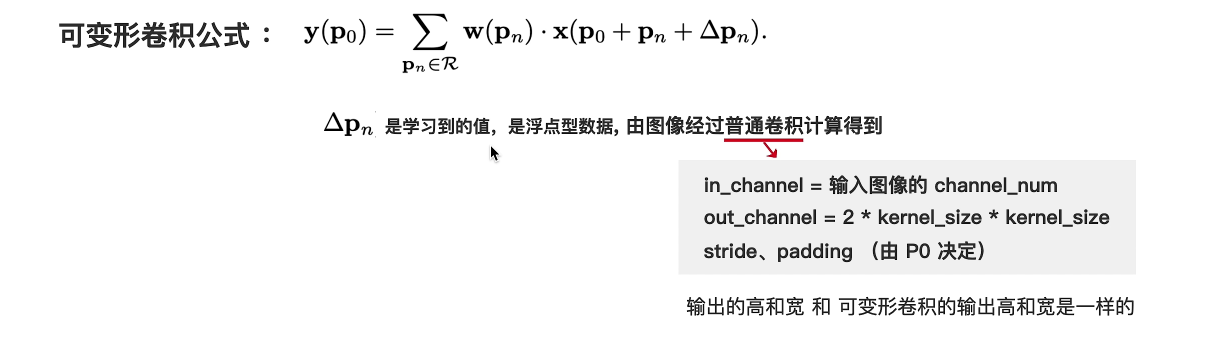

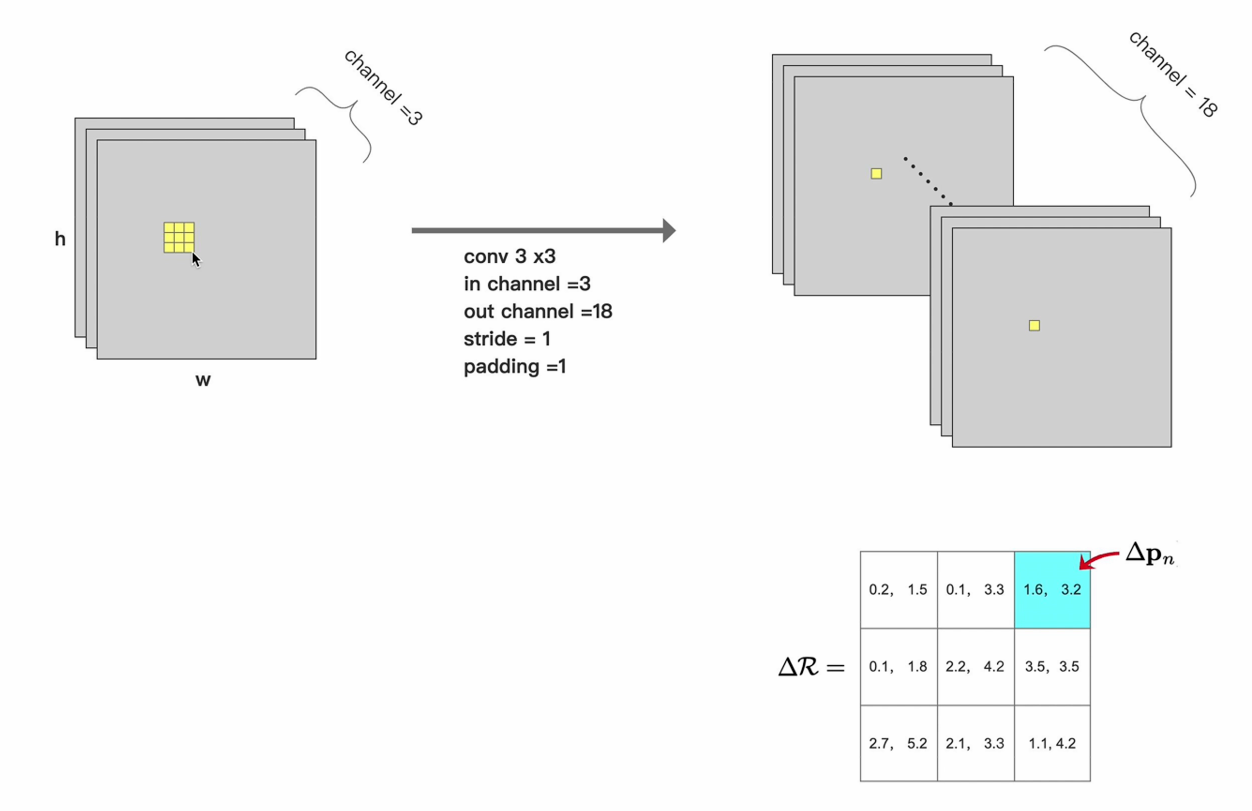

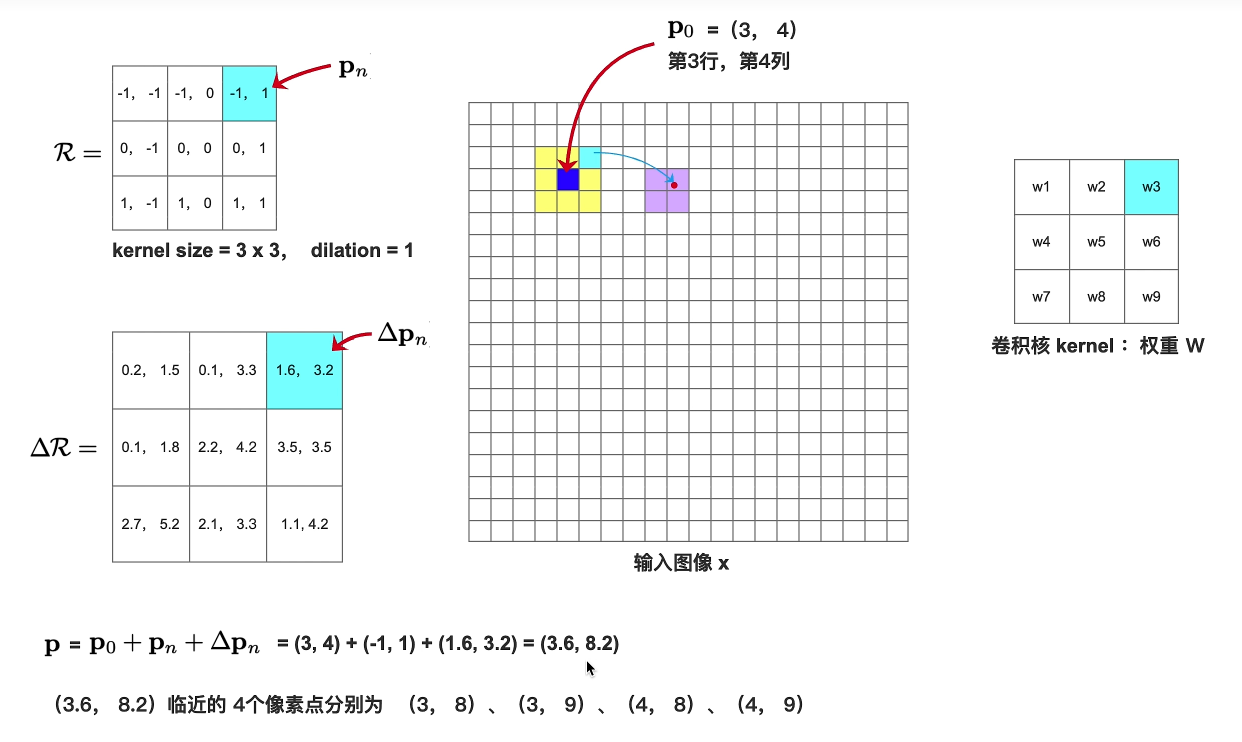

### 1.4 可变形卷积的数学表达：从固定采样到可学习采样

> 这一节把“普通卷积为什么会自然过渡到可变形卷积”写成公式。理解这里以后，再看可变形注意力就会顺很多。

先看普通卷积。对输出位置 $p_0$，普通卷积可以写成：

$$
y(p_0) = \sum_{k=1}^{K} w_k \cdot x(p_0 + p_k)
$$

其中：
- $p_0$ 是当前输出位置。
- $p_k$ 是卷积核的固定采样偏移，例如 $3 \times 3$ 卷积时就是 9 个规则网格点。
- $w_k$ 是对应位置的卷积权重。

这里最关键的是：
- $p_k$ 是手工预先定义好的。
- 网络只能学习权重 $w_k$，不能学习采样位置。

可变形卷积把它改成：

$$
y(p_0) = \sum_{k=1}^{K} w_k \cdot x\big(p_0 + p_k + \Delta p_k\big)
$$

其中新增的 $\Delta p_k$ 就是可学习偏移量。
于是普通卷积里的“固定采样网格”变成了“动态采样网格”。

如果再加上调制系数，也就是 DCNv2 的形式，则常写成：

$$
y(p_0) = \sum_{k=1}^{K} w_k \cdot x\big(p_0 + p_k + \Delta p_k\big) \cdot \Delta m_k
$$

其中：
- $\Delta p_k$ 决定去哪里采样。
- $\Delta m_k$ 决定每个采样点该保留多少强度。

这和后面的可变形注意力已经非常接近了：
- 普通卷积中的固定局部采样点 $p_k$，对应一种规则采样模板。
- 可变形卷积通过 $\Delta p_k$ 让模板随内容变化。
- 可变形注意力进一步把“局部模板”升级成“围绕参考点的稀疏采样集合”，并加入注意力权重融合。

所以你可以把它们看成一条连续演化链：
- 普通卷积：固定采样位置 + 固定局部感受野
- 可变形卷积：可学习采样位置 + 仍然偏局部
- 可变形注意力：可学习采样位置 + 更灵活的全局/半全局稀疏采样

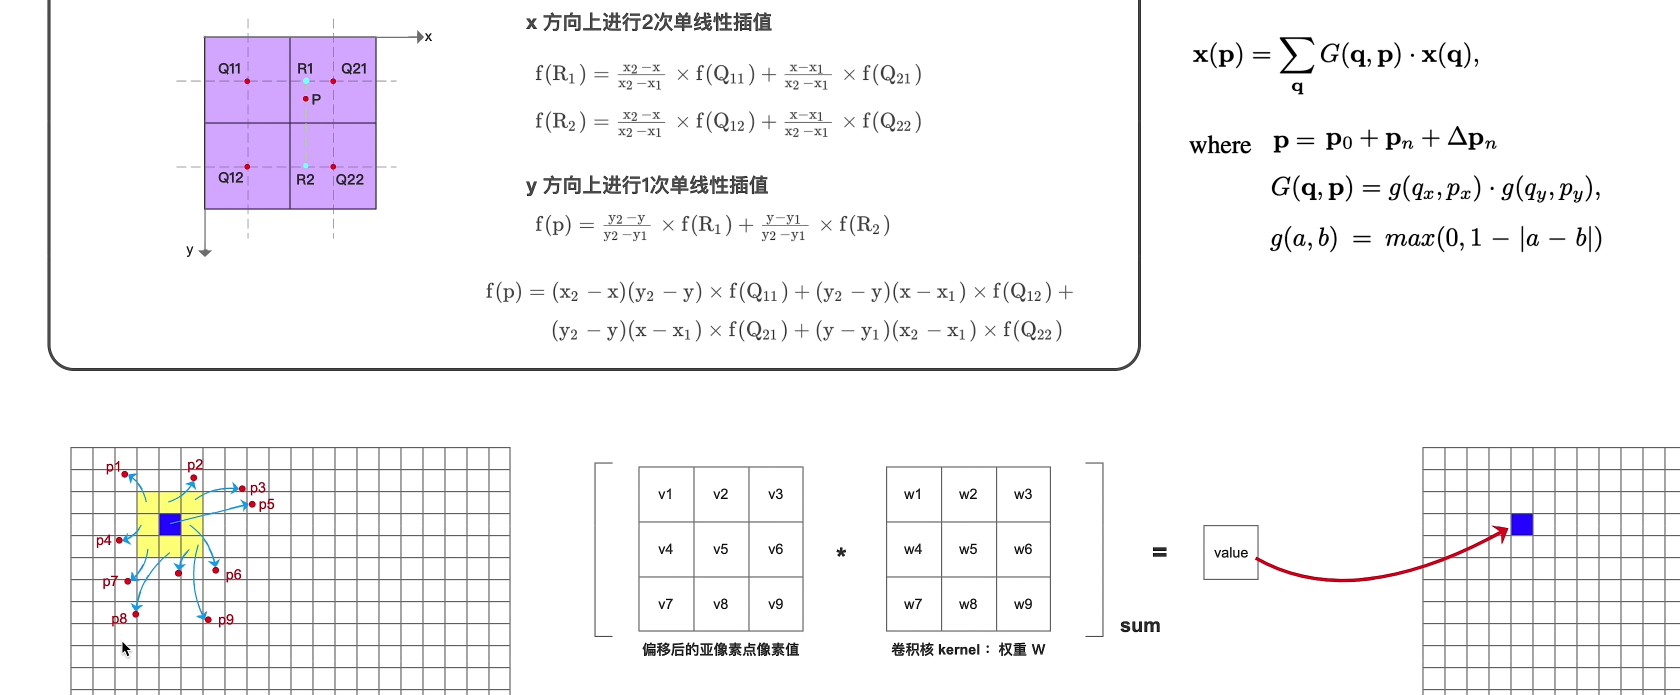

In [ ]:
import itertools
import torch
import torch.nn as nn
import torch.nn.functional as F


class ToyDeformConv2d(nn.Module):
    """
    一个教学版可变形卷积实现：
    - 只演示 stride=1 的二维情况
    - 使用 grid_sample 完成连续坐标采样
    - 追求易读，不追求速度
    """

    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        if kernel_size % 2 == 0:
            raise ValueError("这里为了讲解简单，只支持奇数 kernel_size")

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.padding = padding
        self.num_kernel_points = kernel_size * kernel_size

        # 这个卷积层学习每个采样点的 (x, y) 偏移，输出的每个像素点的所有通道就是采样点的 (x, y) 偏移值
        self.offset_conv = nn.Conv2d(
            in_channels,
            2 * self.num_kernel_points,  #这里是核心，每个采样点需要预测一个 (x, y) 偏移，所以输出通道数是 2 * kernel_size * kernel_size
            kernel_size=3,
            padding=1,
        )

        self.weight = nn.Parameter(
            torch.randn(out_channels, in_channels, self.num_kernel_points) * 0.1
        )
        self.bias = nn.Parameter(torch.zeros(out_channels))

        radius = kernel_size // 2
        rel_coords = list(itertools.product(range(-radius, radius + 1), repeat=2))
        rel_coords = [(dx, dy) for dy, dx in rel_coords]
        self.register_buffer(
            "kernel_grid",
            torch.tensor(rel_coords, dtype=torch.float32),
            persistent=False,
        )

    def forward(self, x):
        batch_size, channels, height, width = x.shape
        padded_x = F.pad(x, (self.padding, self.padding, self.padding, self.padding))
        padded_height = height + 2 * self.padding
        padded_width = width + 2 * self.padding

        # 学习每个采样点的 (x, y) 偏移，输出的 offsets 形状是 (B, 2 * num_kernel_points, height, width)，每个像素点的所有通道就是采样点的 (x, y) 偏移值
        offsets = self.offset_conv(x)
        # 调整 offsets 形状到 (B, num_kernel_points, height, width, 2)，方便后续计算采样位置
        offsets = offsets.view(
            batch_size, self.num_kernel_points, 2, height, width
        ).permute(0, 1, 3, 4, 2).contiguous()

        # 生成基础采样网格，形状为 (1, 1, height, width, 2)，每个位置的值是该位置在输入特征图上的坐标 (x, y)，加上 padding 是为了对应到 padded_x 上
        base_y = torch.arange(height, device=x.device, dtype=x.dtype) + self.padding
        base_x = torch.arange(width, device=x.device, dtype=x.dtype) + self.padding
        # grid_y 和 grid_x 形状都是 (height, width)，分别存储每个位置的 y 坐标和 x 坐标
        grid_y, grid_x = torch.meshgrid(base_y, base_x, indexing="ij")
        base_grid = torch.stack([grid_x, grid_y], dim=-1)
        base_grid = base_grid.view(1, 1, height, width, 2)

        kernel_grid = self.kernel_grid.view(1, self.num_kernel_points, 1, 1, 2).to(x.dtype)
        sampling_locations = base_grid + kernel_grid + offsets

        sampling_grid = sampling_locations.clone()
        sampling_grid[..., 0] = 2.0 * sampling_grid[..., 0] / max(padded_width - 1, 1) - 1.0
        sampling_grid[..., 1] = 2.0 * sampling_grid[..., 1] / max(padded_height - 1, 1) - 1.0

        sampled_features = []
        for point_index in range(self.num_kernel_points):
            point_grid = sampling_grid[:, point_index]
            point_feature = F.grid_sample(
                padded_x,
                point_grid,
                mode="bilinear",
                padding_mode="zeros",
                align_corners=True,
            )
            sampled_features.append(point_feature)

        sampled_features = torch.stack(sampled_features, dim=2)
        output = torch.einsum("bckhw,ock->bohw", sampled_features, self.weight)
        output = output + self.bias.view(1, -1, 1, 1)
        return output

In [4]:
# 构造一个简单输入，方便直观看到采样位置变化对输出的影响
input_tensor = torch.arange(25, dtype=torch.float32).view(1, 1, 5, 5)

toy_deform_conv = ToyDeformConv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1)

with torch.no_grad():
    toy_deform_conv.offset_conv.weight.zero_()
    toy_deform_conv.offset_conv.bias.zero_()
    toy_deform_conv.weight.fill_(1.0)
    toy_deform_conv.bias.zero_()

standard_kernel = torch.ones(1, 1, 3, 3)
regular_conv_output = F.conv2d(input_tensor, standard_kernel, padding=1)
deform_conv_zero_offset_output = toy_deform_conv(input_tensor)

print("输入特征图:\n", input_tensor[0, 0])
print("零偏移时，与普通 3x3 卷积的最大误差:", (regular_conv_output - deform_conv_zero_offset_output).abs().max().item())

with torch.no_grad():
    center_point_index = 4
    toy_deform_conv.offset_conv.bias.zero_()
    toy_deform_conv.offset_conv.bias[2 * center_point_index] = 1.0
    toy_deform_conv.offset_conv.bias[2 * center_point_index + 1] = 0.0

deformed_output = toy_deform_conv(input_tensor)

print("普通卷积在中心位置的输出:", regular_conv_output[0, 0, 2, 2].item())
print("把中心采样点向右偏移 1 个像素后的输出:", deformed_output[0, 0, 2, 2].item())

输入特征图:
 tensor([[ 0.,  1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.,  9.],
        [10., 11., 12., 13., 14.],
        [15., 16., 17., 18., 19.],
        [20., 21., 22., 23., 24.]])
零偏移时，与普通 3x3 卷积的最大误差: 1.9073486328125e-06
普通卷积在中心位置的输出: 108.0
把中心采样点向右偏移 1 个像素后的输出: 109.0


## 2. 从标准注意力一步步走到可变形注意力

> 这一节只做一件事：把“标准注意力”里的元素，平滑地映射到“可变形注意力”里。

### 2.1 标准注意力里，query、key、value 分别是什么

设有一组输入特征 $x$，经过线性映射后得到：
- $Q = xW_Q$
- $K = xW_K$
- $V = xW_V$

对某个 query $q_i$，标准注意力做的是：

$$
\mathrm{Attn}(q_i) = \sum_j \alpha_{ij} v_j, \qquad
\alpha_{ij} = \mathrm{softmax}\left( \frac{q_i k_j^T}{\sqrt{d}} \right)
$$

这里每个元素的含义是：
- `query`：当前我想更新的那个位置或 token。
- `key`：候选信息位置的“索引签名”，用来和 query 算相似度。
- `value`：真正要被取回并聚合的信息。

所以标准注意力本质上是：
- 先拿 query 和所有 key 做匹配。
- 再用匹配分数去加权所有 value。

### 2.2 放到视觉特征图上，会发生什么

如果把一张特征图展平成 $N=H \times W$ 个位置：
- 每个空间位置都可以看成一个 token。
- 每个 query 可能都要和全部 $N$ 个 key 交互。
- 如果 query 数也很多，那么相关性矩阵就会很大。

这就是视觉里标准全局注意力昂贵的根源：
- 不是聚合本身太难。
- 而是“先和所有位置比较一遍”这一步太贵。

### 2.3 一个关键想法：真的需要和所有 key 比吗

在很多视觉任务中，答案通常是否定的。
- 一个目标只和图像中少量区域强相关。
- 一个 BEV 网格点也只会对应少量视角中的局部区域。
- 大量无关位置其实只是陪跑。

于是就有一个自然问题：
- 能不能不要先和所有 key 做匹配？
- 能不能直接预测“应该去哪里看”？

可变形注意力给出的答案就是：可以。

### 2.4 从“全量匹配”变成“稀疏采样”

标准注意力的流程是：
1. 对全部 key 位置做相似度计算。
2. 用 softmax 得到全局权重。
3. 对全部 value 做加权和。

可变形注意力把它改成：
1. 先给每个 query 一个参考点 `reference_point`。
2. 再预测少量采样偏移 `offsets`。
3. 在这些采样位置上，从 value 特征图中取值。
4. 对这些采样值做加权求和。

这意味着：
- 不再显式构造“query 对所有 key”的大矩阵。
- key 不再以“离散候选集合”的方式出现。
- 取而代之的是“连续坐标上的采样位置”。

### 2.5 那 key 去哪了

这是很多人第一次看可变形注意力时最困惑的点。

一个容易理解的说法是：
- 在标准注意力里，key 的职责是“告诉 query 哪些位置相关”。
- 在可变形注意力里，这个职责被“参考点 + 偏移量 + 采样权重”部分接管了。

也就是说，在很多实现里：
- 不再显式地构造一整张 `K` 去和 `Q` 做全量点积。
- 而是由 query 直接预测出该去哪里采样，以及每个采样点该占多大权重。

所以你可以把可变形注意力理解为：
- `query` 仍然存在，而且是核心驱动信号。
- `value` 仍然存在，因为最终被聚合的信息还是来自特征图。
- `key` 的“全局离散匹配”角色被弱化或隐式化，变成了“直接预测采样策略”。

In [5]:
# 一个最小标准注意力例子：1 个 query 对 4x4 特征图的全部位置打分
torch.manual_seed(0)

feature_map = torch.randn(1, 4, 4, 8)
flattened_tokens = feature_map.view(1, 16, 8)

query_token = torch.randn(1, 1, 8)
keys = flattened_tokens
values = flattened_tokens

attention_scores = torch.matmul(query_token, keys.transpose(-1, -2)) / (8 ** 0.5)
attention_weights = torch.softmax(attention_scores, dim=-1)
attention_output = torch.matmul(attention_weights, values)

print("全部候选位置数:", keys.shape[1])
print("attention_weights shape:", attention_weights.shape)
print("权重和是否为 1:", attention_weights.sum(dim=-1))
print("输出向量 shape:", attention_output.shape)
print("注意力最大的空间位置索引:", attention_weights[0, 0].argmax().item())

全部候选位置数: 16
attention_weights shape: torch.Size([1, 1, 16])
权重和是否为 1: tensor([[1.]])
输出向量 shape: torch.Size([1, 1, 8])
注意力最大的空间位置索引: 0


## 3. 输入元素到底是什么：和传统 Q、K、V 的对应关系

> 这一节专门解决“模块输入里每个张量到底代表谁”的问题。

为了便于理解，先看单尺度版本。假设我们有：
- `query`: 形状为 $(B, N_q, C)$
- `value`: 形状为 $(B, H, W, C)$
- `reference_points`: 形状为 $(B, N_q, 2)$

它们分别表示：

### 3.1 query：谁要被更新

`query` 对应标准注意力里的 `Q`。
- 它代表当前要更新的那批查询向量。
- 在检测里，它可以是 object query。
- 在 BEVFormer 里，它可以是 BEV query。
- 在更一般的场景里，它就是“我现在想从特征图里取信息来更新谁”。

所以每个 query 都会独立地产生：
- 一个或多个参考点
- 若干个采样偏移
- 若干个采样权重

### 3.2 value：真正被读取的信息源

`value` 对应标准注意力里的 `V`。
- 它通常来自某张特征图或多层特征图。
- 真正被双线性采样、再被加权融合的内容，就是它。

注意这里 `value` 不是展平的 token 序列，而是保留了二维空间结构的特征图。
这很重要，因为：
- 可变形注意力要在连续坐标上采样。
- 所以保留 $(H, W)$ 的几何布局会更自然。

### 3.3 reference_points：粗定位锚点

`reference_points` 不是标准注意力里的原生元素，它是可变形注意力新增的关键变量。
- 它表示这个 query 大概应该去哪里找信息。
- 可以理解成“粗定位”。
- 后续所有偏移采样，都是围绕它展开。

它的来源依任务而不同：
- 在 Deformable DETR 中，常由 query 经过线性层预测并归一化。
- 在 BEVFormer 中，常与 3D 到 2D 的几何投影有关。

### 3.4 sampling_offsets：细粒度搜索方向

`sampling_offsets` 通常由 query 通过线性层预测得到。
- 形状常写成 $(B, N_q, N_h, K, 2)$。
- 表示每个 query、每个 head、每个采样点的二维偏移。

它的作用相当于：
- 参考点先告诉你“中心大概在哪”。
- 偏移量再告诉你“具体往周围哪些位置看”。

### 3.5 attention_weights：对采样结果做融合

`attention_weights` 同样通常由 query 预测得到。
- 形状常写成 $(B, N_q, N_h, K)$。
- 每个 head 的 $K$ 个采样点会经过 softmax 归一化。

它对应的是注意力里“加权融合”的那部分能力。
只是这里被加权的对象，不再是全部 value 位置，而是少量被采样出来的特征值。

### 3.6 用一句对照总结

把标准注意力和可变形注意力并排看：
- 标准注意力：`query` 与全部 `key` 匹配，再聚合全部 `value`。
- 可变形注意力：`query` 直接预测采样策略，在 `value` 上稀疏取样并聚合。

因此新增的核心对象就是：
- `reference_points`：先去哪里附近看
- `sampling_offsets`：具体采哪些点
- `attention_weights`：这些点如何融合

In [6]:
# 观察 reference_points、sampling_offsets、sampling_locations 的形状与数值关系
batch_size = 1
num_query = 2
num_heads = 2
num_points = 4

reference_points_demo = torch.tensor([[[0.50, 0.50], [0.25, 0.75]]])
sampling_offsets_demo = torch.tensor(
    [[[[[1.0, 0.0], [0.0, 1.0], [-1.0, 0.0], [0.0, -1.0]],
       [[2.0, 0.0], [0.0, 2.0], [-2.0, 0.0], [0.0, -2.0]]],
      [[[1.0, 1.0], [-1.0, 1.0], [-1.0, -1.0], [1.0, -1.0]],
       [[0.5, 0.5], [-0.5, 0.5], [-0.5, -0.5], [0.5, -0.5]]]]],
    dtype=torch.float32,
 )

height, width = 20, 30
normalizer = torch.tensor([width, height], dtype=torch.float32).view(1, 1, 1, 1, 2)
sampling_locations_demo = (
    reference_points_demo[:, :, None, None, :] + sampling_offsets_demo / normalizer
)

print("reference_points shape:", reference_points_demo.shape)
print("sampling_offsets shape:", sampling_offsets_demo.shape)
print("sampling_locations shape:", sampling_locations_demo.shape)
print("第 1 个 query、第 1 个 head 的采样位置:\n", sampling_locations_demo[0, 0, 0])

reference_points shape: torch.Size([1, 2, 2])
sampling_offsets shape: torch.Size([1, 2, 2, 4, 2])
sampling_locations shape: torch.Size([1, 2, 2, 4, 2])
第 1 个 query、第 1 个 head 的采样位置:
 tensor([[0.5333, 0.5000],
        [0.5000, 0.5500],
        [0.4667, 0.5000],
        [0.5000, 0.4500]])


## 4. 数学表达：从标准注意力公式改写到可变形注意力公式

> 这一步不要急着背公式，先看“公式里哪些部分被替换了”。

### 4.1 标准注意力在做什么

对第 $i$ 个 query，标准注意力是：

$$
\mathrm{Attn}(q_i) = \sum_{j=1}^{N} \alpha_{ij} v_j, \qquad
\alpha_{ij} = \mathrm{softmax}\left( \frac{q_i k_j^T}{\sqrt{d}} \right)
$$

这里有两个核心步骤：
- 先对所有 $j$ 计算相关性。
- 再对所有 $v_j$ 做加权和。

### 4.2 可变形注意力改写了哪一步

可变形注意力没有再枚举全部 $j$。
它直接把“遍历所有位置”替换成“只访问少量采样点”。

设：
- query 表示为 $q_i$，共有 $M$ 个 query。
- value 特征图为 $x \in \mathbb{R}^{H \times W \times C}$。
- 第 $i$ 个 query 的参考点为 $p_i \in [0, 1]^2$。
- 第 $m$ 个 head、第 $k$ 个采样点的偏移量为 $\Delta p_{imk}$。
- 对应权重为 $A_{imk}$。

则单尺度可变形注意力写成：

$$
\mathrm{DeformAttn}(q_i, x) = \sum_{m=1}^{N_h} W_m \left( \sum_{k=1}^{K} A_{imk} \cdot x\big(p_i + \Delta p_{imk}\big) \right)
$$

这里要重点理解三件事：
- $x(p_i + \Delta p_{imk})$ 表示通过坐标来索引特征图x
- $p_i + \Delta p_{imk}$ 不一定落在整数网格上，所以要做双线性插值。
- $A_{imk}$ 不是对全图所有位置的权重，而只是对少量采样点的权重。
- 每个 head 可以学习不同的采样模式。

### 4.3 为什么这可以看成“注意力”的一种形式

虽然没有显式写出 $QK^T$，但它仍然具备注意力的两个核心特征：
- 由 query 决定“该关注哪里”。
- 对取回的信息做内容相关的加权融合。

区别只在于：
- 标准注意力通过“和全部 key 匹配”来决定关注位置。
- 可变形注意力通过“直接预测采样位置和权重”来决定关注位置。

### 4.4 多尺度版本再多了什么

如果是多尺度版本，设第 $l$ 层特征图为 $x^l$，则进一步写成：

$$
\mathrm{MSDeformAttn}(q_i) = \sum_{m=1}^{N_h} W_m \left( \sum_{l=1}^{L} \sum_{k=1}^{K} A_{imlk} \cdot x^l\big(p_i^l + \Delta p_{imlk}\big) \right)
$$

这比单尺度只多了一个维度：
- 从一张特征图采样，变成从 $L$ 张不同分辨率特征图采样。

### 4.5 复杂度为什么更低

如果标准注意力要访问全部 $HW$ 个位置，而可变形注意力每个 head 只采样 $K$ 个点，那么：
- 标准注意力的访问规模接近 $HW$。
- 可变形注意力的访问规模接近 $N_h \times K$。

当 $K \ll HW$ 时，节省会非常明显。
这也是它特别适合高分辨率视觉特征的原因。

In [7]:
# 用一个最小例子看“全量加权”和“稀疏采样加权”的差异
value_map = torch.arange(1, 17, dtype=torch.float32).view(1, 4, 4, 1)

# 标准注意力视角：对全部 16 个位置做加权
all_values = value_map.view(1, 16, 1)
dense_weights = torch.softmax(torch.tensor([[0.2] * 16]), dim=-1).view(1, 16, 1)
dense_output = (dense_weights * all_values).sum(dim=1)

# 可变形注意力视角：只取 4 个采样点做加权
sparse_sample_indices = torch.tensor([5, 6, 9, 10])
sparse_values = all_values[:, sparse_sample_indices]
sparse_weights = torch.softmax(torch.tensor([[1.0, 2.0, 2.0, 1.0]]), dim=-1).view(1, 4, 1)
sparse_output = (sparse_weights * sparse_values).sum(dim=1)

print("标准注意力访问的位置数:", all_values.shape[1])
print("可变形注意力访问的位置数:", sparse_values.shape[1])
print("标准注意力输出:", dense_output.squeeze().item())
print("稀疏采样聚合输出:", sparse_output.squeeze().item())

标准注意力访问的位置数: 16
可变形注意力访问的位置数: 4
标准注意力输出: 8.5
稀疏采样聚合输出: 8.5


## 5. 用一个 query 的视角看一遍完整流程

> 如果你总觉得公式里变量太多，可以只盯住“一个 query”来看。

假设：
- 我们当前只看第 $i$ 个 query。
- 它对应一个向量 $q_i \in \mathbb{R}^{C}$。
- 它的参考点是 $p_i=(0.6, 0.4)$，表示大概去特征图右侧偏上区域找信息。
- 现在有 2 个 head，每个 head 采样 4 个点。

那么这个 query 的工作流程可以写成：

### 第一步：先确定大致看哪里

模型先为这个 query 给出一个参考点 $p_i$。
这个点不是最终采样点，而是一个中心锚点。

### 第二步：每个 head 进一步预测偏移

例如某个 head 预测出 4 个偏移：
- $(-0.03, 0.01)$
- $(0.02, -0.04)$
- $(0.00, 0.05)$
- $(0.04, 0.02)$

于是最终采样位置就是：
- $p_i + \Delta p_{i11}$
- $p_i + \Delta p_{i12}$
- $p_i + \Delta p_{i13}$
- $p_i + \Delta p_{i14}$

这些位置通常是浮点坐标，不会正好落在整数像素中心上。

### 第三步：在 value 特征图上取值

因为采样位置是连续坐标，所以不能直接用整数索引。
通常会用双线性插值：
- 找到附近的 4 个离散网格点
- 按距离做加权
- 得到该连续位置的特征向量

这一步就是代码里的 `grid_sample` 在做的事。

### 第四步：对采样到的若干特征做加权融合

假设这个 head 对 4 个采样点预测出的权重是：

$$
[0.1, 0.2, 0.5, 0.2]
$$

那么这个 head 的输出就是：

$$
0.1 v_1 + 0.2 v_2 + 0.5 v_3 + 0.2 v_4
$$

其中 $v_1, v_2, v_3, v_4$ 是 4 个采样位置通过双线性插值得到的特征向量。

### 第五步：多个 head 的结果再拼起来

每个 head 都会做一遍“预测偏移 -> 采样 -> 加权求和”。
最后把所有 head 的结果拼接起来，再过一个线性层，得到这个 query 的更新结果。

所以整个过程本质上是：
- query 不再对全图搜索。
- query 直接决定采样策略。
- value 特征图作为被读取的信息源。

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SimplifiedDeformableAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, num_points):
        super().__init__()
        if embed_dim % num_heads != 0:
            raise ValueError("embed_dim 必须能被 num_heads 整除")

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.num_points = num_points
        self.head_dim = embed_dim // num_heads

        self.value_proj = nn.Linear(embed_dim, embed_dim)
        self.offset_proj = nn.Linear(embed_dim, num_heads * num_points * 2)
        self.weight_proj = nn.Linear(embed_dim, num_heads * num_points)
        self.output_proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, query, value, reference_points):
        """
        query: (B, Nq, C)
            要被更新的查询向量，对应标准注意力中的 Q
        value: (B, H, W, C)
            被采样和聚合的特征图，对应标准注意力中的 V
        reference_points: (B, Nq, 2)
            每个 query 的粗定位锚点，坐标范围为 [0, 1]
        """
        batch_size, num_query, _ = query.shape
        _, height, width, _ = value.shape

        # 先把 value 投影到多头注意力所需的通道空间
        # 形状: (B, H, W, C) -> (B, H, W, num_heads * head_dim) -> (B*num_heads, head_dim, H, W)
        projected_value = self.value_proj(value)
        projected_value = projected_value.view(
            batch_size, height, width, self.num_heads, self.head_dim
        )
        projected_value = projected_value.permute(0, 3, 4, 1, 2).contiguous()
        projected_value = projected_value.view(
            batch_size * self.num_heads, self.head_dim, height, width
        )

        # 由 query 直接预测采样偏移和采样权重
        # sampling_offsets 形状: (B, Nq, num_heads * num_points * 2) -> (B, Nq, num_heads, num_points, 2)
        # 这里2表示每个采样点的 (x, y) 偏移,num_points 表示每个 head 的采样点数量，这些采样点的数量也就是最终用来做加权融合的点的数量
        sampling_offsets = self.offset_proj(query)
        sampling_offsets = sampling_offsets.view(
            batch_size, num_query, self.num_heads, self.num_points, 2
        )

        # attention_weights 形状: (B, Nq, num_heads * num_points) -> (B, Nq, num_heads, num_points)
        # 为什么是这样，因为每个query 对每个 head 的 num_points 个采样点都要预测一个权重，这些权重会用来对采样到的特征做加权融合
        attention_weights = self.weight_proj(query)
        attention_weights = attention_weights.view(
            batch_size, num_query, self.num_heads, self.num_points
        )
        # 经过 softmax 归一化后，attention_weights 就可以看作是每个 query 对其采样点的注意力分布了
        attention_weights = F.softmax(attention_weights, dim=-1)

        # 把偏移量从像素尺度归一化到 [0, 1] 参考系
        normalizer = query.new_tensor([width, height])
        # 创建一个与 query 张量具有相同设备（device）和数据类型（dtype）的新张量，并用列表 [width, height] 中的值填充形状是(2,),tenser([width, height]) 
        normalizer = normalizer.view(1, 1, 1, 1, 2)
        # (batch_size, num_heads, num_queries, num_points, 2)，最后两位是 (x, y) 坐标的最大值，即宽度高度
        # (B, Nq, num_heads, num_points, 2)/(1, 1, 1, 1, 2) -> (B, Nq, num_heads, num_points, 2)，
        # 每个采样点的偏移量除以最大值都被归一化了
        sampling_locations = (
            reference_points[:, :, None, None, :] + sampling_offsets / normalizer
        )

        # grid_sample 需要 [-1, 1] 坐标，且最后一维顺序是 (x, y)
        sampling_grid = sampling_locations * 2.0 - 1.0
        # 形状： (B, Nq, num_heads, num_points, 2) -> (B, num_heads, Nq, num_points, 2) -> (B*num_heads, Nq, num_points, 2)
        sampling_grid = sampling_grid.permute(0, 2, 1, 3, 4).contiguous()
        sampling_grid = sampling_grid.view(
            batch_size * self.num_heads, num_query, self.num_points, 2
        )

        # 在连续坐标上做双线性采样
        # (B*num_heads, head_dim, H, W)，value图二维的作为 grid_sample 的查询依据
        # (B*num_heads, Nq, num_points, 2)，
        # 每个采样点的坐标是(x_norm, y_norm),-1 和 1 分别对应输入特征图最左侧像素的中心和最右侧像素的中心
        # 反归一化得到浮点数的索引，然后进行双线性插值采样，得到每个采样点的特征值
        sampled_value = F.grid_sample(
            projected_value,  #输入特征图，形状为 (N, C, H_in, W_in)
            sampling_grid,   #采样网格，形状为 (N, H_out, W_out, 2)
            mode="bilinear",
            padding_mode="zeros",
            align_corners=False,
        )
        # 输出形状为 (N, C, H_out, W_out)
        # 采样结果形状: (B*num_heads, head_dim, Nq, num_points) -> (B, num_heads, head_dim, Nq, num_points)
        sampled_value = sampled_value.view(
            batch_size, self.num_heads, self.head_dim, num_query, self.num_points
        )
        # 调整维度顺序到 (B, num_heads, Nq, num_points, head_dim)，方便后续加权融合
        sampled_value = sampled_value.permute(0, 3, 1, 4, 2).contiguous()

        # 对每个 head 的若干采样点做加权融合
        # attention_weights 形状: (B, Nq, num_heads, num_points) -> (B, Nq, num_heads, num_points, 1)，
        attention_weights = attention_weights.unsqueeze(-1)
        # sampled_value 形状: (B, Nq, num_heads, num_points, head_dim)* (B, Nq, num_heads, num_points, 1) -> (B, Nq, num_heads, head_dim)，
        # 相当于每个 query 每个 head 的 num_points 个采样点的特征值根据 attention_weights 预测的权重做加权求和，得到每个 head 的输出特征
        output = (sampled_value * attention_weights).sum(dim=3)
        # 调整维度顺序到 (B, Nq, num_heads * head_dim) -> (B, Nq, C)
        output = output.view(batch_size, num_query, self.embed_dim)
        # 最后再经过一个线性投影，得到最终的输出特征
        output = self.output_proj(output)
        # 输出形状: (B, Nq, C)
        return output

总结起来，就是由 query 直接预测采样偏移和采样权重，value 投影到多头注意力所需的通道空间，作为被查询的二维图，query得到的偏移量加上传入的参考点得到绝对位置坐标，然后进行归一化，再使用value构建的图与query的绝对归一化坐标双线性插值，得到num_point个实际用于加权求和的value，最后有attention_weight和num_points个value进行加权得到最终输出，输出与query形状一致。

In [2]:
batch_size = 2
num_query = 6
height, width = 20, 30
embed_dim = 64
num_heads = 8
num_points = 4

torch.manual_seed(0)

module = SimplifiedDeformableAttention(
    embed_dim=embed_dim,
    num_heads=num_heads,
    num_points=num_points,
)

query = torch.randn(batch_size, num_query, embed_dim)
value = torch.randn(batch_size, height, width, embed_dim)
reference_points = torch.rand(batch_size, num_query, 2)

output = module(query, value, reference_points)
print("query shape:", query.shape)
print("value shape:", value.shape)
print("reference_points shape:", reference_points.shape)
print("output shape:", output.shape)

query shape: torch.Size([2, 6, 64])
value shape: torch.Size([2, 20, 30, 64])
reference_points shape: torch.Size([2, 6, 2])
output shape: torch.Size([2, 6, 64])


## 6. 代码实现逐段解释：把概念和代码一一对上

> 这一版代码是教学版，不是官方高性能 CUDA 版本，但逻辑链路是完整的。

### 6.1 为什么代码里几乎看不到显式的 key

这段代码里你会发现：
- 有 `query`
- 有 `value`
- 但没有单独写出一个 `key` 张量

原因不是 key 不重要，而是这份简化实现采用了可变形注意力里更容易理解的一种视角：
- 让 `query` 直接预测采样位置和采样权重
- 不再显式构造“query 与全体 key 的相似度矩阵”

所以这里相当于把标准注意力里的：
- “通过 key 找相关位置”
改成了：
- “直接预测该采样哪些位置”

### 6.2 `value_proj` 在做什么

`value_proj` 对 `value` 做线性映射：
- 输入还是空间特征图
- 但通道会被投影到当前注意力模块所用的嵌入空间

随后代码把它 reshape 成多头形式。
这一步对应的是：
- 不同 head 各自处理一部分通道
- 每个 head 后续会学习不同的采样模式

### 6.3 `offset_proj` 和 `weight_proj` 在做什么

这两个线性层都只吃 `query`：
- `offset_proj(query)` 预测采样偏移
- `weight_proj(query)` 预测采样权重

这正是“由 query 决定采样策略”的代码体现。
也就是说，query 不再先去和所有 key 打分，而是直接输出：
- 去哪采
- 采几点
- 每个点占多少比重

### 6.4 为什么要除以 `[width, height]`

代码里有一步：

```python
normalizer = query.new_tensor([width, height]).view(1, 1, 1, 1, 2)
sampling_locations = reference_points[:, :, None, None, :] + sampling_offsets / normalizer
```

这是因为：
- `reference_points` 用的是归一化坐标 $[0,1]$
- 而偏移量通常更接近像素尺度的位移概念

所以要把偏移量也缩放到同一个参考系，再和参考点相加。

### 6.5 `grid_sample` 为什么是关键

`grid_sample` 的作用可以概括成一句话：
- 给我一组连续坐标，我帮你从二维特征图上做双线性插值取值。

这一步非常关键，因为采样点通常不是整数网格点。
如果没有这一步：
- 采样位置只能落在离散像素上
- 偏移量的连续可学习性就会大打折扣

所以从实现角度说：
- 可变形注意力能“可变形”
- 很大程度上就依赖这种连续坐标采样机制

### 6.6 最后那一步加权求和，对应的是哪部分注意力

代码最后：

```python
output = (sampled_value * attention_weights).sum(dim=3)
```

这一步就是注意力里的“聚合”。
只不过聚合对象不再是全图所有 value，而是少量采样得到的 value。

所以把它和标准注意力对照起来：
- 标准注意力：对全部 value 做加权和
- 可变形注意力：对少量采样 value 做加权和

### 6.7 这份简化代码省略了什么

为了教学清晰，这里刻意省略了一些工程细节：
- 没有实现多尺度 feature level
- 没有实现更复杂的 reference point 生成方式
- 没有使用官方 CUDA kernel 做高效采样
- 没有处理更复杂的 mask 与 padding 逻辑

但对理解原理来说，它已经保留了最核心的 4 件事：
- query 驱动采样策略
- reference point 提供粗定位
- offsets 提供细粒度采样
- sampled value 再经过 attention weights 融合

## 7. 和 BEVFormer 中用法的关系

> 当你把前面的概念吃透，再看 BEVFormer，就不会觉得“为什么又冒出参考点和采样点”。

可以这样理解：
- 每个 BEV query 对应鸟瞰图上的一个网格位置。
- 这个位置通过相机外参与内参，可以投影到各个相机视角图像上。
- 投影结果提供了一个很自然的参考点。
- 接着模型再围绕这个参考点学习少量偏移做细粒度采样。
- 来自不同相机、不同尺度的采样结果再融合回这个 BEV query。

所以 BEVFormer 中的空间交叉注意力，本质上就是：
- 几何投影先给一个粗定位。
- 可变形注意力再做内容相关的稀疏采样。
- 最后把多视角信息聚合回 BEV 空间。

如果你准备继续扩展这份笔记，比较自然的下一步有两个：
1. 补上 multi-scale deformable attention 的完整张量形状推导。
2. 单独再写一节“BEV query 如何投影到图像平面”的几何过程。